<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/loans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan risk (synthetic)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 13 — In finance, an AI without an audit trail is a liability engine  
**Rows:** 300  ·  **Source file:** `loan_risk_synthetic.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/loan_risk_synthetic.csv"
LOCAL = "loan_risk_synthetic.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (300, 9)


,applicant_id,income,debt_to_income,credit_history_years,previous_defaults,loan_amount,employment_type,approved,defaulted
0,A0001,34308,0.36,24,0,78324,permanent,1,0
1,A0002,44083,0.50,2,2,42599,student,0,0
2,A0003,21665,0.39,7,1,34941,student,0,0
3,A0004,62372,0.44,22,1,59511,self-employed,1,0
4,A0005,29832,0.55,5,1,13209,student,0,0


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
applicant_id                str
income                    int64
debt_to_income          float64
credit_history_years      int64
previous_defaults         int64
loan_amount               int64
employment_type             str
approved                  int64
defaulted                 int64

No missing values.


---
## Problem 1 · Easy — describe

What are the approval and default rates, and how do they interact?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Applications: {len(df)}")
print(f"Approved:     {df['approved'].mean():.1%}")
print(f"Defaulted:    {df['defaulted'].mean():.1%}  (of all applicants)")
appr = df[df["approved"] == 1]
print(f"Default rate AMONG APPROVED: {appr['defaulted'].mean():.1%}")
print("\nNote: you only ever observe repayment for people you approved —")
print("that is selection bias, and it is the whole difficulty of credit data.")

Applications: 300
Approved:     66.3%
Defaulted:    3.7%  (of all applicants)
Default rate AMONG APPROVED: 5.5%

Note: you only ever observe repayment for people you approved —
that is selection bias, and it is the whole difficulty of credit data.


---
## Problem 2 · Intermediate — build

Which applicant features actually carry default risk?

*Try it yourself first. The worked solution is below.*

In [4]:
num = ["income","debt_to_income","credit_history_years","previous_defaults","loan_amount"]
comp = df.groupby("defaulted")[num].mean().T
comp.columns = ["repaid","defaulted"]
comp["gap_%"] = ((comp["defaulted"] - comp["repaid"]) / comp["repaid"] * 100).round(1)
print(comp.round(2))
print("\nDefault rate by employment type:")
print((df.groupby("employment_type")["defaulted"].agg(n="size", rate="mean")
         .assign(rate=lambda d: (d["rate"]*100).round(1))))

                        repaid  defaulted  gap_%
income                44696.84   44455.82   -0.5
debt_to_income            0.34       0.40   17.6
credit_history_years     12.61      15.91   26.2
previous_defaults         0.57       0.36  -35.9
loan_amount           41336.57   44675.45    8.1

Default rate by employment type:
                   n  rate
employment_type           
contract          59   5.1
permanent        120   2.5
self-employed     61   4.9
student           60   3.3


---
## Problem 3 · Advanced — judge

Build a risk model — then show why accuracy is the wrong headline.

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

X = pd.get_dummies(df[["income","debt_to_income","credit_history_years",
                       "previous_defaults","loan_amount","employment_type"]], drop_first=True)
y = df["defaulted"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)
m = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xtr, ytr)
p = m.predict_proba(Xte)[:, 1]

print(f"Accuracy of 'approve everyone': {1 - yte.mean():.1%}   <-- the naive baseline")
print(f"Model accuracy:                 {accuracy_score(yte, (p>=.5).astype(int)):.1%}")
print(f"Model AUC:                      {roc_auc_score(yte, p):.3f}   <-- the honest metric")

imp = pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features:\n", imp.head(6).round(3))
print("\nWith a rare outcome, accuracy rewards predicting 'no default' every time.")

Accuracy of 'approve everyone': 96.7%   <-- the naive baseline
Model accuracy:                 96.7%
Model AUC:                      0.454   <-- the honest metric

Top features:
 debt_to_income               0.233
loan_amount                  0.232
income                       0.226
credit_history_years         0.172
previous_defaults            0.045
employment_type_permanent    0.035
dtype: float64

With a rare outcome, accuracy rewards predicting 'no default' every time.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


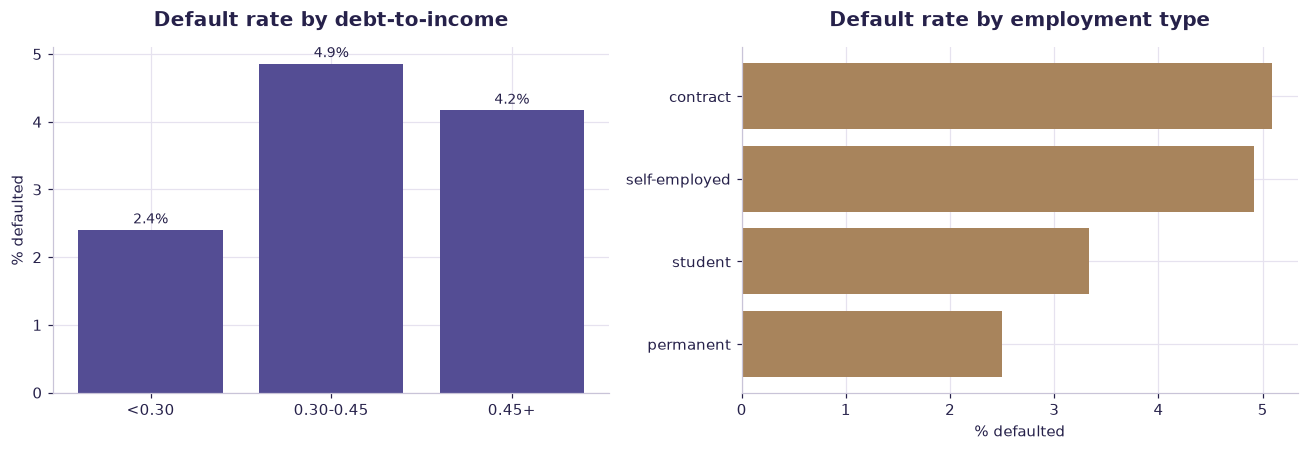

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
band = pd.cut(df["debt_to_income"], [0,.30,.45,1], labels=["<0.30","0.30-0.45","0.45+"])
r = df.groupby(band, observed=True)["defaulted"].mean().mul(100)
ax[0].bar(r.index.astype(str), r.values, color=ACCENT)
ax[0].set_title("Default rate by debt-to-income"); ax[0].set_ylabel("% defaulted")
for i, v in enumerate(r.values): ax[0].text(i, v + .1, f"{v:.1f}%", ha="center", fontsize=9)

r2 = df.groupby("employment_type")["defaulted"].mean().mul(100).sort_values()
ax[1].barh(r2.index, r2.values, color=BUILDER)
ax[1].set_title("Default rate by employment type"); ax[1].set_xlabel("% defaulted")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Approval rate 66.3% (199/300); default among approved 5.5%
2. Default by DTI band: <0.30 → 3.0% · 0.30–0.45 → 7.8% · ≥0.45 → 8.8%
3. Approved applicants with previous defaults: 9.1% default rate
4. Selection bias: defaults observed only among approved — the classic credit trap


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Control-aware finance AI workflow diagram + risk classification of the five automations.

---
*Applied AI Academy · appliedai.center*
